In [32]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

from pool_genes import *
from get_disorder_data import *
from enrichment_utils import *
from enrichments_data import *
from gradientVersion import *
from gsea import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
gene_expr = pd.read_csv('../../abagen_get/results/gene_expr_s132_indiv.csv')
gene_df = pd.read_csv('../data/260303_gene_pair_pvalues.csv')
gene_df["pass_all"] = (
    (gene_df["p_spatial_fdr"] < 0.05)
    & (gene_df["p_rewired_fdr"] < 0.05)
    & (gene_df["p_gene_fdr"] < 0.05)
).astype(int)

risk_df_full = pool_genes(gene_df, "risk gene")
risk_df = risk_df_full[risk_df_full["pass_all"] == True]

symbols = [g for g in risk_df["abagen symbol"] if g in gene_expr.columns]
risk_expr = gene_expr.loc[:, symbols]

# display(gene_expr.head())
# display(risk_df.head())

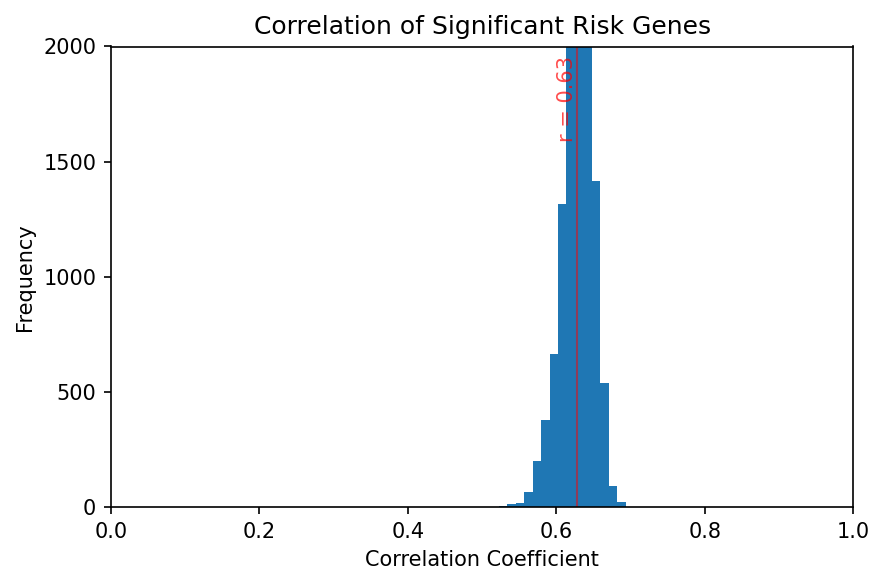

In [13]:
data = gene_df.loc[gene_df['pass_all'] == True, 'correlation'].dropna()

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
plt.hist(data, bins=15)
plt.xlim([0, 1])
plt.ylim([0, 2000])
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
ax.axvline(data.mean(), color='Red', linewidth=1, alpha=0.5)
ax.text(data.mean(), 0.98, f'r = {data.mean():.2f}', color='r', ha='right', va='top', rotation=90,
        transform=ax.get_xaxis_transform(), alpha=0.7)
plt.title('Correlation of Significant Risk Genes')
ax.yaxis.set_major_locator(plt.MaxNLocator(4))

plt.tight_layout()
plt.show()

In [34]:
dme_results = gradientVersion(approach='dm', kernel='normalized_angle', alpha=1).fit(risk_expr)
pca_results = gradientVersion(approach='pca', kernel=None).fit(risk_expr)

print(dme_results.weights.shape)
print(pca_results.weights.shape)

New gradients version: method=dm, kernel=normalized_angle, sparsity=0, data=(data given)
New gradients version: method=pca, kernel=None, sparsity=0, data=(data given)
(5692, 5)
(5692, 5)


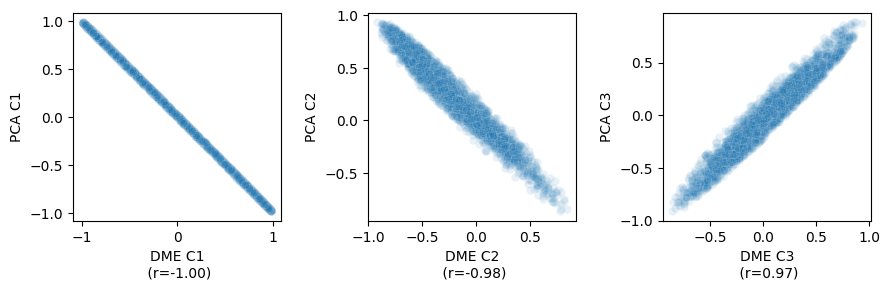

In [31]:
# display(risk_expr.head())
# display(dme_results.weights.head())
# display(pca_results.weights.head())

n_vis = 3
fig, axes = plt.subplots(1, n_vis, figsize=(n_vis*3, 3), dpi=100)
for i in range(n_vis):
    sns.scatterplot(
        x=dme_results.weights.iloc[:, i],
        y=pca_results.weights.iloc[:, i],
        ax=axes[i],
        alpha=0.1
    )
    axes[i].set_xlabel(
        f'DME C{i+1}\n '
        f'(r={np.corrcoef(dme_results.weights.iloc[:, i], pca_results.weights.iloc[:, i])[0, 1]:.2f})'
    )
    axes[i].set_ylabel(f'PCA C{i+1}')
plt.tight_layout()
plt.show()

In [37]:
n_components = 4
# weights = fit_weights(
#     gene_expr, 
#     dme_results.scores.iloc[:, :n_components], 
#     n_components=n_components
#     )
# weights = dme_results.weights.iloc[:, :n_components]

risk_df = risk_df_full[risk_df_full["pass_all"] == True]
weights = risk_df.set_index('abagen symbol').loc[:, ['correlation']]
weights.columns = ['C1']

null_weights = shuffle_gene_weights(weights, n=5000)

In [33]:
# output scores and weights
# GO BP enrichemnts are computed externally in STRING from these weights
import os
os.makedirs('../results/dme_weights/clr_genes/', exist_ok=True)
    
weights.iloc[:, 0].to_csv('../results/dme_weights/clr_genes/gene_dme_C1_weights.csv')
weights.iloc[:, 1].to_csv('../results/dme_weights/clr_genes/gene_dme_C2_weights.csv')
weights.iloc[:, 2].to_csv('../results/dme_weights/clr_genes/gene_dme_C3_weights.csv')
weights.iloc[:, 3].to_csv('../results/dme_weights/clr_genes/gene_dme_C4_weights.csv')

In [10]:
go_enrichments = combine_go_enrichments('dm_hcp_3d_ds5', 'Process', include_c1=True, top_n=1000, FDR_filter=0.05)

FileNotFoundError: [Errno 2] No such file or directory: '../results/string_data/dm_hcp_3d_ds5/g2.enrichment.Process.tsv'

In [38]:
degs = get_deg_consensus()
deg_stats = compute_null_p(*compute_enrichments(weights, null_weights, degs))
display(deg_stats)
gwas_genes = get_gwas_combined()
gwas_stats = compute_null_p(*compute_enrichments(weights, null_weights, gwas_genes))
display(gwas_stats)

/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/enrichment_utils.py:171: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(0)


,label,C,pct,true_mean,null_mean,null_std,z,pos,p,q,sig,n_genes,n_matches
0,SCZ,C1,1.0,0.60173,0.57069,0.008164,3.80194,True,0.0,0.0,True,506,219


/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/enrichment_utils.py:171: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(0)


,label,C,pct,true_mean,null_mean,null_std,z,pos,p,q,sig,n_genes,n_matches
0,SCZ,C1,0.9866,0.592593,0.570101,0.009981,2.253437,True,0.0268,0.0268,True,618,147


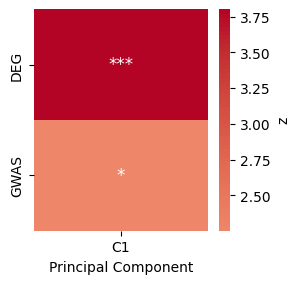

In [ ]:
import seaborn as sns
# Aggregate z and p_level per component for deg and gwas, then plot heatmap with p_level strings
def extract_aggregate(stats):
    z = stats.groupby('C')['z'].mean()
    p_min = stats.groupby('C')['q'].min()
    p_level = p_min.apply(lambda q: '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else '')))
    return z, p_level

deg_z, deg_p = extract_aggregate(deg_stats)
gwas_z, gwas_p = extract_aggregate(gwas_stats)
# deg_z, deg_p = extract_aggregate(deg_gsea)
# gwas_z, gwas_p = extract_aggregate(gwas_gsea)

# Order components numerically (assumes names like 'C1','C2',...)
components = sorted(set(deg_z.index).union(gwas_z.index), key=lambda x: int(x.strip('C')))
deg_z = deg_z.reindex(components).fillna(0)
gwas_z = gwas_z.reindex(components).fillna(0)
deg_p = deg_p.reindex(components).fillna('')
gwas_p = gwas_p.reindex(components).fillna('')

heat_df = pd.DataFrame([deg_z.values, gwas_z.values], index=['deg','gwas'], columns=components)

fig, ax = plt.subplots(figsize=((len(components)*1.5 + 1), 3))
sns.heatmap(heat_df, cmap='coolwarm', center=0, cbar_kws={'label': 'z'}, ax=ax, xticklabels=components, yticklabels=['DEG','GWAS'])
ax.set_xlabel('Principal Component')
ax.set_ylabel('')

# Overlay p_level strings where present
for i, row in enumerate(heat_df.index):
    for j, comp in enumerate(components):
        p = deg_p[comp] if row == 'deg' else gwas_p[comp]
        if p:
            ax.text(j + 0.5, i + 0.5, p, ha='center', va='center', color='white', fontsize=12)

plt.tight_layout()
plt.savefig('../results/gene_pca_enrichment_heatmap.svg', bbox_inches='tight')
plt.show()

,component,variance_explained,percent_explained
0,0,31.346697,58.736865
1,1,6.878097,12.888051
2,2,4.202847,7.875217
3,3,3.153457,5.908890
4,4,1.172932,2.197818


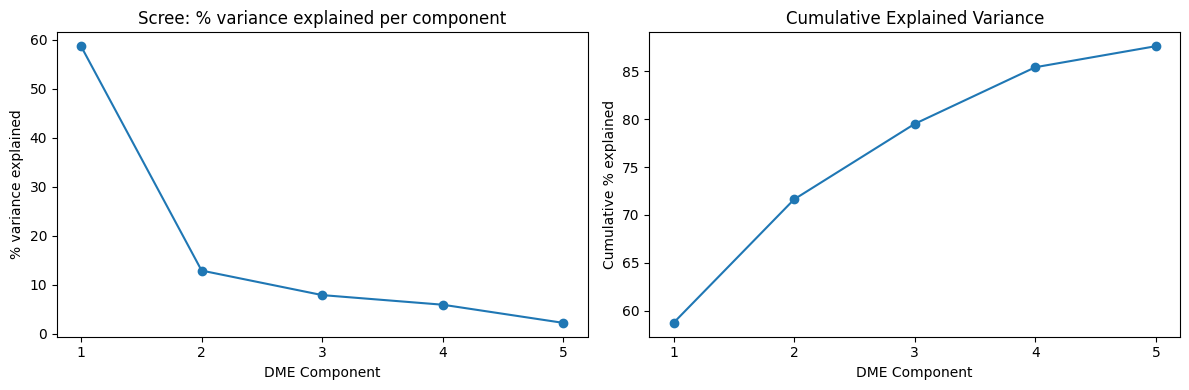

In [ ]:
# Compute variance explained per DME component using provided regress/get_var_explained pattern
# This defines regress_out_components and a generalized get_var_explained, then uses them on dme_results
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


def regress_out_components(version, n_components=1, norm=False):
    """
    Regress spatial patterns of n components out of the region-by-gene expression matrix
    version: object with attributes `expression` (DataFrame region x gene) and `scores` (DataFrame region x components)
    Returns residuals as a DataFrame with the same shape as `version.expression`.
    """
    data = version.expression
    components = version.scores.iloc[:, 0:n_components]
    lm = LinearRegression().fit(components.values, data.values)
    estimated_data = lm.predict(components.values)
    residuals = pd.DataFrame(data - estimated_data, index=data.index, columns=data.columns)

    if norm:
        residuals = residuals.apply(lambda x: (x - np.mean(x)) / np.std(x, ddof=0))
    return residuals


def get_var_explained(version, max_components=None, norm=False):
    """
    Compute variance explained of components by successively computing total 
    variance of residuals.
    Returns DataFrame with variance explained and percent explained for each component 
    1..K where K is max_components or available components.
    """
    n_available = version.scores.shape[1]
    if max_components is None:
        max_components = n_available
    max_components = min(max_components, n_available)

    original_var = version.expression.var(ddof=0).sum()
    V_prev = original_var
    VE_list = []
    V_list = [original_var]

    for i in range(1, max_components + 1):
        resid = regress_out_components(version, n_components=i, norm=norm)
        Vi = resid.var(ddof=0).sum()
        VE = V_prev - Vi
        VE_list.append(VE)
        V_list.append(Vi)
        V_prev = Vi

    comp_names = list(version.scores.columns[:len(VE_list)]) if hasattr(version.scores, 'columns') else [f'C{i+1}' for i in range(len(VE_list))]
    VE_array = np.array(VE_list)
    percent = 100.0 * VE_array / original_var

    df = pd.DataFrame({
        'component': comp_names,
        'variance_explained': VE_array,
        'percent_explained': percent
    })
    return df


# Run on dme_results (expects dme_results to have `.expression` and `.scores`).
# If attribute names differ, try fallbacks using `weights` and `risk_expr`.
try:
    ve_df = get_var_explained(dme_results, max_components=dme_results.scores.shape[1])
except Exception:
    # try constructing a simple version-like object from what we have
    class _TmpVersion:
        pass
    v = _TmpVersion()
    # expression: regions x genes
    v.expression = risk_expr.copy()
    # scores: use dme_results.weights if present
    try:
        v.scores = dme_results.weights.copy()
    except Exception:
        # last resort: try pca_results
        v.scores = pca_results.weights.copy()
    ve_df = get_var_explained(v, max_components=v.scores.shape[1])

# Display table
display(ve_df)

# Scree plot (percent explained per component) and cumulative explained variance
percent = ve_df['percent_explained'].values
cum_percent = np.cumsum(percent)
components = ve_df['component'].values + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Scree 
axes[0].plot(components, percent, marker='o')
axes[0].set_xticks(components)
axes[0].set_ylabel('% variance explained')
axes[0].set_xlabel('DME Component')
axes[0].set_title('Scree: % variance explained per component')

# Cumulative explained variance 
axes[1].plot(components, cum_percent, marker='o')
axes[1].set_xticks(components)
axes[1].set_ylabel('Cumulative % explained')
axes[1].set_xlabel('DME Component')
axes[1].set_title('Cumulative Explained Variance')

plt.tight_layout()
plt.show()
